#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Titanic

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=darkblue> 1 - Imports e declaração de constantes

### <font color=steelblue> 1.1 - Imports

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde
import numpy as np
import requests
from scipy.stats import pearsonr

### <font color=steelblue> 1.2 - Constantes

Declarar constantes em uma unica celula facilita a manutenção de notebooks longos.<br>Alguns benefícios:
1. Melhorar a legibilidade do codigo
2. As constantes podem ser esquema de cores para padronizar sempre as mesmas cores para determinadas classes, paths de arquivos e datasets e etc.
3. posso modifica-las apenas aqui e servir para o codigo inteiro


In [ ]:
# paths dos arquivos originais professor + Bank of England
PATH_TITANIC = "SEU PATH/titanic.csv"
PATH_BOE = "SEU PATH/a-millennium-of-macroeconomic-data-for-the-uk.xlsx"

# paths dos arquivos feitos na feature engineering
PATH_BOE_CPI = "SEU PATH/boe_cpi.csv"
PATH_WB_CPI = "SEU PATH/extras/wb_cpi.csv"

# endpoint de APIs
# cpi -> consumer price index. é o indexador de inflacao
API_WORLD_BANK = "https://api.worldbank.org/v2/country/GBR/indicator/FP.CPI.TOTL"

# paleta de cores para deixar os graficos padronizados
CORES = [
    "#4878D0",
    "#EE854A",
    "#6ACC64",
    "#D65F5F",
    "#956CB4",
]

# tamanho padrão dos graficos
FIGSIZE = (10, 5)

# constantes para variaveis qualitativas e cabecalho
LABELS_CLASSE = {1: "Primeira Classe", 2: "Segunda Classe", 3: "Terceira Classe"}

CLASSES = list(LABELS_CLASSE.values())

LABELS_GENERO = {"male": "Masculino", "female": "Feminino"}

LABELS_SOBREVIVENTE = {0: "Não Sobreviveu", 1: "Sobreviveu"}

MAP_COLUMNS = {
    "Survived": "Sobreviveu",
    "Pclass": "Classe",
    "Name": "Nome",
    "Sex": "Genero",
    "Age": "Idade",
    "Siblings/Spouses Aboard": "Irmãos/Cônjuges a Bordo",
    "Parents/Children Aboard": "Pais/Filhos a Bordo",
    "Fare": "Tarifa",
}

## <font color=darkblue> 2 - Carregamento e Preparação do Dataset

### <font color=steelblue> 2.1 - Carregando o dataset original

**Observações**<br>
Esta análise considera `exclusivamente os passageiros do Titanic`. Algumas decisões metodológicas foram adotadas para garantir maior clareza e consistência nos resultados:

1. Registros com `Fare = 0` foram excluídos, pois não é possível distinguir se pertencem a passageiros ou tripulantes, e sua presença poderia distorcer métricas e visualizações.
2. As variáveis qualitativas já são carregadas com mapeamento pelos valores definidos nas constantes, padronizando rótulos em tabelas e gráficos sem necessidade de configuração adicional.
3. Por essas razões, pequenas variações nos cálculos de média, mediana, desvio padrão e outras medidas em relação a outras análises do mesmo dataset são esperadas.

In [57]:
# carregando o dataset já renomeado com as constantes definidas na seçao 1.2
titanic_df = pd.read_csv(PATH_TITANIC, header=0, names=MAP_COLUMNS.values())

# como explicado, filtro quem estava no titanic que tinha fare =0
titanic_df = titanic_df[titanic_df["Tarifa"] > 0]

titanic_df["Classe"] = titanic_df["Classe"].map(LABELS_CLASSE)
titanic_df["Genero"] = titanic_df["Genero"].map(LABELS_GENERO)
titanic_df["Sobreviveu"] = titanic_df["Sobreviveu"].map(LABELS_SOBREVIVENTE)
titanic_df.tail(1)

,Sobreviveu,Classe,Nome,Genero,Idade,Irmãos/Cônjuges a Bordo,Pais/Filhos a Bordo,Tarifa
886,Não Sobreviveu,Terceira Classe,Mr. Patrick Dooley,Masculino,32.0,0,0,7.75


### <font color=steelblue> 2.2 - Feature Engineering

**Observações:**<br>
Em aula, o professor falou da importancia de considerar tanto valores absolutos quanto relativos. No caso do Titanic, como o acidente ocorreu em 1912, as tarifas originais estão completamente defasadas: £1 de 1912 não equivale a £1 hoje. <br><br>
Para preservar a noção de grandeza e permitir uma interpretação mais realista dos preços e do quão luxuoso uma passagem de 1 classe seria, adicionei uma coluna com a tarifa corrigida pela inflação. Os índices utilizados foram:

1. `Bank of England` - A Millennium of Macroeconomic Data for the UK (v3.1), aba A47, coluna H. Índice composto de preços do Reino Unido, normalizado para 100 em 2016. Cobre o período de 1912 a 2016.
2. `World Bank` - utilizado para estender a correção de 2016 até os anos mais recentes, complementando a série histórica do BoE.


#### <font color=slategray> 2.2.1 - Aquisição de dados externos

In [58]:
'''
# essa celula é pra rodar só uma vez e depois comentar.
# ela salva os datasets obtidos de APIs e dados externos para nao precisar puxar toda execucao


# extrai do Excel e salva em csv para evitar reler o arquivo de 27MB a cada execução
boe_df = pd.read_excel(
    PATH_BOE,
    sheet_name='A47. Wages and prices',
    header=6,       # as 6 primeiras linhas são metadados; a linha 6 é o cabeçalho real
    usecols=[0, 3], # col 0 = ano, col 3 = CPI preferred measure (GB/UK, base 2015=100)
)
boe_df.columns = ['Ano', 'Indice_CPI']
boe_df = boe_df.dropna(subset=['Ano', 'Indice_CPI'])
boe_df['Ano'] = boe_df['Ano'].astype(int)
boe_df.to_csv(PATH_BOE_CPI, index=False)

# obtém CPI de 2016 até 2024 via API e salva em csv pra nao chamar a API toda hora
# CPI é como se fosse a inflacao do UK -> Consumer Price Index
resp = requests.get(
    API_WORLD_BANK,
    params={"format": "json", "date": "2016:2024", "per_page": 20},
    timeout=10,
)
wb_df = pd.DataFrame(resp.json()[1])[["date", "value"]].dropna()
wb_df.columns = ['Ano', 'Indice_CPI']
wb_df['Ano'] = wb_df['Ano'].astype(int)
wb_df.to_csv(PATH_WB_CPI, index=False)

'''

'\n# essa celula é pra rodar só uma vez e depois comentar.\n# ela salva os datasets obtidos de APIs e dados externos para nao precisar puxar toda execucao\n\n\n# extrai do Excel e salva em csv para evitar reler o arquivo de 27MB a cada execução\nboe_df = pd.read_excel(\n    PATH_BOE,\n    sheet_name=\'A47. Wages and prices\',\n    header=6,       # as 6 primeiras linhas são metadados; a linha 6 é o cabeçalho real\n    usecols=[0, 3], # col 0 = ano, col 3 = CPI preferred measure (GB/UK, base 2015=100)\n)\nboe_df.columns = [\'Ano\', \'Indice_CPI\']\nboe_df = boe_df.dropna(subset=[\'Ano\', \'Indice_CPI\'])\nboe_df[\'Ano\'] = boe_df[\'Ano\'].astype(int)\nboe_df.to_csv(PATH_BOE_CPI, index=False)\n\n# obtém CPI de 2016 até 2024 via API e salva em csv pra nao chamar a API toda hora\n# CPI é como se fosse a inflacao do UK -> Consumer Price Index\nresp = requests.get(\n    API_WORLD_BANK,\n    params={"format": "json", "date": "2016:2024", "per_page": 20},\n    timeout=10,\n)\nwb_df = pd.DataFr

#### <font color=slategray> 2.2.2 - Fator de inflação

In [ ]:
# carrega os csvs salvos localmente, agora nao depende de API.
boe_df = pd.read_csv(PATH_BOE_CPI)
wb_df = pd.read_csv(PATH_WB_CPI)

# fator BoE: corrige de 1912 até 2016
idx_1912 = boe_df.loc[boe_df["Ano"] == 1912, "Indice_CPI"].values[0]
idx_2016 = boe_df.loc[boe_df["Ano"] == 2016, "Indice_CPI"].values[0]
fator_boe = idx_2016 / idx_1912

# fator World Bank: estende a correção de 2016 até 2024
cpi_2016 = wb_df.loc[wb_df["Ano"] == 2016, "Indice_CPI"].values[0]
cpi_2024 = wb_df.loc[wb_df["Ano"] == 2024, "Indice_CPI"].values[0]
fator_wb = cpi_2024 / cpi_2016

# constante do indice de inflacao
FATOR_INFLACAO = fator_boe * fator_wb

In [60]:
resumo_inflacao = pd.DataFrame(
    [
        {
            "Fonte": "Bank of England",
            "Período": "1912 → 2016",
            "Fator": f"{fator_boe:.2f}",
        },
        {"Fonte": "World Bank", "Período": "2016 → 2024", "Fator": f"{fator_wb:.4f}"},
        {"Fonte": "Total", "Período": "1912 → 2024", "Fator": f"{FATOR_INFLACAO:.2f}"},
    ]
)
print("Tabela 2.2.1 — Composição do fator de correção da inflação (1912 → 2024)")
display(resumo_inflacao.set_index("Fonte"))

Tabela 2.2.1 — Composição do fator de correção da inflação (1912 → 2024)


,Período,Fator
Fonte,,
Bank of England,1912 → 2016,81.46
World Bank,2016 → 2024,1.3153
Total,1912 → 2024,107.14


In [61]:
# aqui eu adiciono uma nova coluna para o dataset: tarifa atualizada com a inflacao
titanic_df["Tarifa 2024"] = (titanic_df["Tarifa"] * FATOR_INFLACAO).round(2)
titanic_df.tail(1)

,Sobreviveu,Classe,Nome,Genero,Idade,Irmãos/Cônjuges a Bordo,Pais/Filhos a Bordo,Tarifa,Tarifa 2024
886,Não Sobreviveu,Terceira Classe,Mr. Patrick Dooley,Masculino,32.0,0,0,7.75,830.3


### <font color=steelblue> 2.3 - Visão geral das features

In [62]:
visao_geral = pd.DataFrame(
    {
        "Tipo": titanic_df.dtypes,
        "Não nulos": titanic_df.notna().sum(),
        "Nulos": titanic_df.isna().sum(),
    }
)
visao_geral.index.name = "Coluna"

print(f"Tabela 2.3 - Visão geral das features ({len(titanic_df)} registros)")
display(visao_geral)

Tabela 2.3 - Visão geral das features (872 registros)


,Tipo,Não nulos,Nulos
Coluna,,,
Sobreviveu,str,872,0
Classe,str,872,0
Nome,str,872,0
Genero,str,872,0
Idade,float64,872,0
Irmãos/Cônjuges a Bordo,int64,872,0
Pais/Filhos a Bordo,int64,872,0
Tarifa,float64,872,0
Tarifa 2024,float64,872,0


### <font color=steelblue> 2.4 - Faixa etária

In [63]:
bins = [0, 12, 17, 59, 100]
labels = ["Criança", "Jovem", "Adulto", "Idoso"]

titanic_df["Faixa_Etaria"] = pd.cut(
    titanic_df["Idade"], bins=bins, labels=labels, right=True
)

print("Tabela 2.4 — Distribuição por faixa etária")
display(
    titanic_df["Faixa_Etaria"]
    .value_counts()
    .sort_index()
    .rename("Passageiros")
    .to_frame()
)

Tabela 2.4 — Distribuição por faixa etária


,Passageiros
Faixa_Etaria,
Criança,79
Jovem,51
Adulto,711
Idoso,31


## <font color=darkblue> 3 - Análise exploratória dos dados

### <font color=steelblue> 3.1 - Visão geral do dataset

In [64]:
print("Tabela 3.1 — Estatísticas descritivas do dataset Titanic")
display(titanic_df.describe().T)

Tabela 3.1 — Estatísticas descritivas do dataset Titanic


,count,mean,std,min,25%,50%,75%,max
Coluna,,,,,,,,
Idade,872.0,29.432534,14.185683,0.4200,20.000,28.00,38.000,80.0000
Irmãos/Cônjuges a Bordo,872.0,0.534404,1.111968,0.0000,0.000,0.00,1.000,8.0000
Pais/Filhos a Bordo,872.0,0.389908,0.812807,0.0000,0.000,0.00,0.000,6.0000
Tarifa,872.0,32.861133,50.026480,4.0125,7.925,14.50,31.275,512.3292
Tarifa 2024,872.0,3520.605906,5359.630692,429.8800,849.050,1553.47,3350.670,54888.8400


### <font color=steelblue> 3.2 - Identificação das variáveis

Tabela com detalhes pedidos no briefing do projeto onde temos que identificar e classificas as features

In [65]:
# funcao para pegar os valores unicos das qualitativas separados por '/'
def valores_possiveis(col):
    return " / ".join(titanic_df[col].unique())

In [66]:
variaveis = pd.DataFrame(
    [
        {
            "Variável": "Sobreviveu",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": valores_possiveis("Sobreviveu"),
        },
        {
            "Variável": "Classe",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": valores_possiveis("Classe"),
        },
        {
            "Variável": "Nome",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": "Único por passageiro",
        },
        {
            "Variável": "Genero",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": valores_possiveis("Genero"),
        },
        {
            "Variável": "Idade",
            "Tipo": "Quantitativa",
            "Subtipo": "Contínua",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Irmãos/Cônjuges a Bordo",
            "Tipo": "Quantitativa",
            "Subtipo": "Discreta",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Pais/Filhos a Bordo",
            "Tipo": "Quantitativa",
            "Subtipo": "Discreta",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Tarifa",
            "Tipo": "Quantitativa",
            "Subtipo": "Contínua",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Tarifa 2024",
            "Tipo": "Quantitativa",
            "Subtipo": "Contínua",
            "Valores Possíveis": "—",
        },
    ]
)

# tirei o o maximo de caracteres para aparecer todos os valores
print("Tabela 3.2 — Identificação das variáveis do dataset Titanic")
with pd.option_context("display.max_colwidth", None):
    display(variaveis.set_index("Variável"))

Tabela 3.2 — Identificação das variáveis do dataset Titanic


,Tipo,Subtipo,Valores Possíveis
Variável,,,
Sobreviveu,Qualitativa,—,Não Sobreviveu / Sobreviveu
Classe,Qualitativa,—,Terceira Classe / Primeira Classe / Segunda Classe
Nome,Qualitativa,—,Único por passageiro
Genero,Qualitativa,—,Masculino / Feminino
Idade,Quantitativa,Contínua,—
Irmãos/Cônjuges a Bordo,Quantitativa,Discreta,—
Pais/Filhos a Bordo,Quantitativa,Discreta,—
Tarifa,Quantitativa,Contínua,—
Tarifa 2024,Quantitativa,Contínua,—


### <font color=steelblue> 3.3 - Frequência da tarifa

#### <font color=slategray> 3.3.1 - Cálculo do bins

In [67]:
# aqui eu calculo o numero teorico de bins de acordo com o que foi ensinado em sala
# largura = (máximo - mínimo) / n_bins

n_bins = np.sqrt(len(titanic_df)).astype(int)

print(n_bins)

29


#### <font color=slategray> 3.3.2 - Histograma da tarifa (corrigido com inflação até 2024)

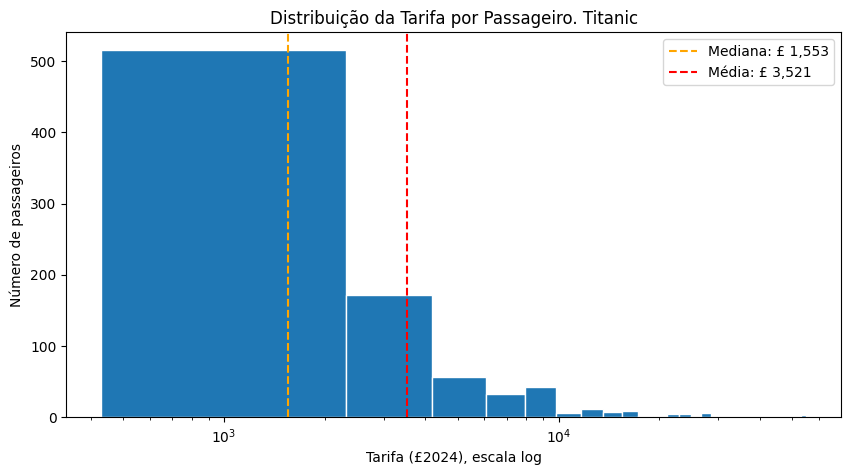

In [ ]:
tarifas = titanic_df["Tarifa 2024"]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(tarifas, bins=n_bins, edgecolor="white")

# como o histograma tem uma distribuição assimetrica para direita, utilizei a scala log como foi pedido no pdf
ax.set_xscale("log")
ax.set_xlabel("Tarifa (£2024), escala log")
ax.set_ylabel("Número de passageiros")
ax.set_title("Distribuição da Tarifa por Passageiro. Titanic")

# criação de linhas com as medidas de tendencia central
ax.axvline(
    tarifas.median(),
    color="orange",
    linestyle="--",
    label=f"Mediana: £ {tarifas.median():,.0f}",
)
ax.axvline(
    tarifas.mean(), color="red", linestyle="--", label=f"Média: £ {tarifas.mean():,.0f}"
)
ax.legend()
plt.savefig("assets/titanic/hist_fare.png")
plt.show()

**Observações:**
- distribuição assimétrica à direita
- mediana: £ 1,553. média: £ 3.521. razão de ~2.3x
- concentração de tarifas elevadas em poucos passageiros
- distância grande entre média e mediana

### <font color=steelblue> 3.4 - Frequência da idade

#### <font color=slategray> 3.4.1 - Histograma da idade

In [ ]:
idades = titanic_df["Idade"].dropna()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(idades, bins=n_bins, edgecolor="white")

# curva de densidade
# aqui eu já escalonei para voltar a unidade real
x_range = np.linspace(idades.min(), idades.max(), 300)
bin_width = (idades.max() - idades.min()) / n_bins
kde = gaussian_kde(idades)
kde_scaled = kde(x_range) * len(idades) * bin_width

ax.plot(x_range, kde_scaled, color="green", label="Densidade")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Número de passageiros")
ax.set_title("Distribuição da Idade por Passageiro. Titanic")

ax.axvline(
    idades.median(),
    color="orange",
    linestyle="--",
    label=f"Mediana: {idades.median():.1f} anos",
)
ax.axvline(
    idades.mean(), color="red", linestyle="--", label=f"Média: {idades.mean():.1f} anos"
)

ax.legend()
plt.savefig("assets/titanic/hist_age.png")
plt.show()

**Observações:**
- distribuição aproximadamente simétrica, levemente assimétrica à direita
- mediana e média próximas (~28 e ~29 anos), indicando menor influência de valores extremos que na tarifa
- concentração de passageiros entre 20 e 40 anos
- presença de crianças visível nas primeiras barras, mas em menor proporção

### <font color=steelblue> 3.5 - Distribuição das variáveis qualitativas

Para as variáveis qualitativas, cada gráfico é composto por dois painéis: à esquerda, um gráfico de barras com os valores absolutos, e à direita, um gráfico de pizza com as proporções relativas. 

A variável `Nome` foi excluída desta seção por funcionar como identificador único

#### <font color=slategray> 3.5.1 - Gênero

In [ ]:
contagem = titanic_df["Genero"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE)

barras = ax1.bar(contagem.index, contagem.values, color=CORES[: len(contagem)])
ax1.bar_label(barras)
ax1.set_ylabel("Número de passageiros")
ax1.set_title("Gênero — Contagem")

ax2.pie(
    contagem,
    labels=contagem.index,
    autopct="%1.1f%%",
    colors=CORES[: len(contagem)],
    wedgeprops={"edgecolor": "white"},
)
ax2.set_title("Gênero — Proporção")

plt.suptitle("Distribuição por Gênero. Titanic")
plt.tight_layout()
plt.savefig("assets/titanic/gender.png")
plt.show()

**Observações:**
- maioria masculina: ~65% dos passageiros eram homens
- mulheres representavam apenas ~35% dos passageiros a bordo

#### <font color=slategray> 3.5.2 - Classe

In [ ]:
contagem = titanic_df["Classe"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE)

barras = ax1.bar(contagem.index, contagem.values, color=CORES[: len(contagem)])
ax1.bar_label(barras)
ax1.set_ylabel("Número de passageiros")
ax1.set_title("Classe — Contagem")

ax2.pie(
    contagem,
    labels=contagem.index,
    autopct="%1.1f%%",
    colors=CORES[: len(contagem)],
    wedgeprops={"edgecolor": "white"},
)
ax2.set_title("Classe — Proporção")

plt.suptitle("Distribuição por Classe. Titanic")
plt.tight_layout()
plt.savefig("assets/titanic/class.png")
plt.show()

**Observações:**
- terceira classe concentra a maior parte dos passageiros (~55%), seguida pela primeira (~24%) e segunda (~21%)
- distribuição desigual entre classes, com mais passageiros nas classes mais baratas

#### <font color=slategray> 3.5.3 - Sobrevivência

In [ ]:
contagem = titanic_df["Sobreviveu"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE)

barras = ax1.bar(contagem.index, contagem.values, color=CORES[: len(contagem)])
ax1.bar_label(barras)
ax1.set_ylabel("Número de passageiros")
ax1.set_title("Sobrevivência — Contagem")

ax2.pie(
    contagem,
    labels=contagem.index,
    autopct="%1.1f%%",
    colors=CORES[: len(contagem)],
    wedgeprops={"edgecolor": "white"},
)
ax2.set_title("Sobrevivência — Proporção")

plt.suptitle("Distribuição por Sobrevivência. Titanic")
plt.tight_layout()
plt.savefig("assets/titanic/survival.png")
plt.show()

**Observações:**
- maioria não sobreviveu: ~62% dos passageiros morreram no naufrágio
- taxa de sobrevivência de ~38%, evidenciando a gravidade do acidente


### <font color=steelblue> 3.6 - Densidade da tarifa por classe

In [ ]:
x_range = np.logspace(0, np.log10(titanic_df["Tarifa 2024"].max()), 500)

fig, ax = plt.subplots(figsize=FIGSIZE)
for i, classe in enumerate(CLASSES):
    dados = titanic_df[titanic_df["Classe"] == classe]["Tarifa 2024"]
    kde = gaussian_kde(np.log(dados))
    densidade = kde(np.log(x_range)) / x_range
    ax.plot(
        x_range,
        densidade,
        color=CORES[i],
        linewidth=2.5,
        label=f"{classe} (n={len(dados)})",
    )
    ax.fill_between(x_range, densidade, alpha=0.2, color=CORES[i])

ax.set_xscale("log")
ax.set_xlabel("Tarifa (£2024), escala log")
ax.set_ylabel("Densidade")
ax.set_title("Densidade da Tarifa por Classe. Titanic")
ax.legend()
plt.tight_layout()
plt.savefig("assets/titanic/density.png")
plt.show()

**Observações:**
- 3a classe: pico próximo a £ 900. passageiros concentrados entre £ 600 e £ 3.400
- 2a classe: dois picos em torno de £ 1.500 e £ 3.000. dois subgrupos com precificações distintas
- 1a classe: distribuição longa com tarifas que chegam a £ ~55.000. alta variabilidade interna

### <font color=steelblue> 3.7 - Perfil dos sobreviventes

#### <font color=slategray> 3.7.1 - Por classe

In [ ]:
tabela = titanic_df.groupby(["Classe", "Sobreviveu"]).size().unstack(fill_value=0)
tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=FIGSIZE)
bottom = np.zeros(len(tabela_pct))
for i, col in enumerate(tabela_pct.columns):
    barras = ax.bar(
        tabela_pct.index, tabela_pct[col], bottom=bottom, color=CORES[i], label=col
    )
    ax.bar_label(barras, fmt="%.1f%%", label_type="center")
    bottom += tabela_pct[col].values

ax.set_ylabel("% de passageiros")
ax.set_title("Sobrevivência por Classe. Titanic")
ax.legend()
plt.tight_layout()
plt.savefig("assets/titanic/survival_class.png")
plt.show()

**Observações:**
- primeira classe apresenta a maior taxa de sobrevivência (~63%), seguida pela segunda (~47%) e terceira (~24%)
- a diferença entre primeira e terceira classe é de quase 40 pontos percentuais
- quanto mais baixa a classe, menor proporção de sobreviventes

#### <font color=slategray> 3.7.2 - Por gênero

In [ ]:
tabela = titanic_df.groupby(["Genero", "Sobreviveu"]).size().unstack(fill_value=0)
tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=FIGSIZE)
bottom = np.zeros(len(tabela_pct))
for i, col in enumerate(tabela_pct.columns):
    barras = ax.bar(
        tabela_pct.index, tabela_pct[col], bottom=bottom, color=CORES[i], label=col
    )
    ax.bar_label(barras, fmt="%.1f%%", label_type="center")
    bottom += tabela_pct[col].values

ax.set_ylabel("% de passageiros")
ax.set_title("Sobrevivência por Gênero. Titanic")
ax.legend()
plt.tight_layout()
plt.savefig("assets/titanic/survival_gender.png")
plt.show()

**Observações:**
- mulheres apresentam taxa de sobrevivência muito superior a dos homens (~73% vs ~19%)
- a diferença entre os gêneros é superior a 50 pontos percentuais


#### <font color=slategray> 3.7.3 - Por faixa etária

In [ ]:
tabela = (
    titanic_df.groupby(["Faixa_Etaria", "Sobreviveu"], observed=True)
    .size()
    .unstack(fill_value=0)
)
tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=FIGSIZE)
bottom = np.zeros(len(tabela_pct))
for i, col in enumerate(tabela_pct.columns):
    barras = ax.bar(
        tabela_pct.index, tabela_pct[col], bottom=bottom, color=CORES[i], label=col
    )
    ax.bar_label(barras, fmt="%.1f%%", label_type="center")
    bottom += tabela_pct[col].values

ax.set_ylabel("% de passageiros")
ax.set_title("Sobrevivência por Faixa Etária. Titanic")
ax.legend()
plt.tight_layout()
plt.savefig("assets/titanic/survival_group_age.png")
plt.show()

**Observações:**
- crianças apresentam a maior taxa de sobrevivência
- adultos concentram o maior volume de passageiros e a menor taxa de sobrevivência relativa

### <font color=steelblue> 3.8 - Boxplot e percentis

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE)

ax1.boxplot(
    titanic_df["Idade"].dropna(),
    patch_artist=True,
    boxprops={"facecolor": CORES[0]},
    medianprops={"color": "black", "linewidth": 2},
)
ax1.axhline(
    titanic_df["Idade"].quantile(0.10),
    linestyle="--",
    color=CORES[2],
    linewidth=1,
    label="P10",
)
ax1.axhline(
    titanic_df["Idade"].quantile(0.90),
    linestyle="--",
    color=CORES[3],
    linewidth=1,
    label="P90",
)
ax1.set_ylabel("Idade (anos)")
ax1.set_title("Boxplot — Idade")
ax1.legend()

ax2.boxplot(
    titanic_df["Tarifa 2024"],
    patch_artist=True,
    boxprops={"facecolor": CORES[1]},
    medianprops={"color": "black", "linewidth": 2},
)
ax2.axhline(
    titanic_df["Tarifa 2024"].quantile(0.10),
    linestyle="--",
    color=CORES[2],
    linewidth=1,
    label="P10",
)
ax2.axhline(
    titanic_df["Tarifa 2024"].quantile(0.90),
    linestyle="--",
    color=CORES[3],
    linewidth=1,
    label="P90",
)
ax2.set_yscale("log")
ax2.set_ylabel("Tarifa (£2024), escala log")
ax2.set_title("Boxplot — Tarifa 2024")
ax2.legend()

plt.suptitle("Quartis das variáveis quantitativas. Titanic")
plt.tight_layout()
plt.savefig("assets/titanic/boxplot.png")
plt.show()

In [78]:
percentis = titanic_df["Idade"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
percentis.index = ["P10", "Q1 (P25)", "Q2 (P50)", "Q3 (P75)", "P90"]
percentis.name = "Idade (anos)"

print("Tabela 3.8.2 — Percentis da Idade")
display(percentis.to_frame())

Tabela 3.8.2 — Percentis da Idade


,Idade (anos)
P10,14.05
Q1 (P25),20.00
Q2 (P50),28.00
Q3 (P75),38.00
P90,49.00


In [79]:
percentis = titanic_df["Tarifa 2024"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
percentis.index = ["P10", "Q1 (P25)", "Q2 (P50)", "Q3 (P75)", "P90"]
percentis.name = "Tarifa 2024 (£)"

print("Tabela 3.8.3 — Percentis da Tarifa 2024")
display(percentis.to_frame())

Tabela 3.8.3 — Percentis da Tarifa 2024


,Tarifa 2024 (£)
P10,828.555
Q1 (P25),849.050
Q2 (P50),1553.470
Q3 (P75),3350.670
P90,8352.130


**Observações:**
- o boxplot visualiza a dispersão das variáveis quantitativas por meio dos quartis: Q1 (P25), mediana (P50) e Q3 (P75), com os bigodes se estendendo até os valores extremos não considerados outliers
- adicionei linhas tracejadas para P10 e P90, ampliando a leitura dos extremos da distribuição além dos quartis convencionais
- para a tarifa, o eixo y está em escala logarítmica dado o elevado grau de assimetria e a presença de outliers extremos
- as tabelas de percentis a seguir complementam o gráfico com os valores exatos de cada linha

### <font color=steelblue> 3.9 - Dispersão e correlação entre idade e tarifa

O coeficiente de Pearson foi calculado de duas formas complementares:

- `pearsonr()` da biblioteca `scipy.stats`: retorna o coeficiente `r` e o p-valor, permitindo avaliar não só a força da correlação mas também sua significância estatística
- `corr()` da biblioteca `pandas`: método aplicado diretamente sobre o DataFrame, calcula automaticamente a correlação entre todas as colunas numéricas selecionadas e é visualizado como matriz de correlação

Ambas as abordagens produzem o mesmo coeficiente de Pearson, conforme exigido pelo briefing do trabalho.

In [ ]:
dados = titanic_df[["Idade", "Tarifa 2024", "Sobreviveu"]].dropna()
r, p_valor = pearsonr(dados["Idade"], dados["Tarifa 2024"])

fig, ax = plt.subplots(figsize=FIGSIZE)

for i, sobrev in enumerate(sorted(dados["Sobreviveu"].unique())):
    label = LABELS_SOBREVIVENTE.get(sobrev, str(sobrev))
    grupo = dados[dados["Sobreviveu"] == sobrev]
    ax.scatter(
        grupo["Idade"],
        grupo["Tarifa 2024"],
        alpha=0.5,
        color=CORES[i],
        label=label,
        s=20,
        edgecolors="none",
    )

ax.set_yscale("log")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Tarifa (£2024), escala log")
ax.set_title(f"Dispersão: Idade × Tarifa 2024 | r de Pearson = {r:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("assets/titanic/scatter_pearson.png")
plt.show()

resultado = pd.Series(
    {"Coeficiente de Pearson (r)": round(r, 3), "p-valor": round(p_valor, 4)},
    name="Idade × Tarifa 2024"
)
print("Tabela 3.9 — Correlação de Pearson")
display(resultado.to_frame())

In [ ]:
corr = titanic_df[["Idade", "Tarifa 2024"]].corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)), corr.columns)
ax.set_yticks(range(len(corr.index)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center", color="black")
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.savefig("assets/titanic/matriz_correlacao.png")
plt.show()

**Observações:**
- o coeficiente de correlação de Pearson entre idade e tarifa é próximo de zero, indicando baixa correlação
- a nuvem de pontos confirma essa ausência de tendência linear

## <font color=darkblue> 4 - Síntese e conclusões

A análise descritiva do dataset Titanic permitiu caracterizar o perfil dos passageiros, identificar padrões de sobrevivência e explorar as relações entre as features. Esta seção reúne as principais interpretações, indo além da descrição numérica para contextualizar os resultados.

### <font color=steelblue> 4.1 - Perfil socioeconômico dos passageiros

- maioria dos passageiros era da terceira classe (`~55%`), do sexo masculino (`~65%`) e em idade adulta
- a distribuição da tarifa é fortemente assimétrica à direita: a mediana é inferior à média, indicando que poucos passageiros pagaram valores muito elevados
- a correção inflacionária torna os valores concretos e dão contexto: a tarifa mais cara registrada no dataset equivale a aproximadamente `£ 55.000` em 2024, o que corresponde a cerca de `R$ 400.000`, evidenciando o nível de exclusividade das acomodações de primeira classe
- a distribuição da idade é aproximadamente simétrica, com mediana próxima de 28 anos, retratando uma população predominantemente em idade ativa

### <font color=steelblue> 4.2 - Fatores associados à sobrevivência

- `a sobrevivência não foi aleatória`: classe, gênero e faixa etária são fatores com padrões claros nos dados
- passageiros da primeira classe sobreviveram em proporção muito maior que os da terceira, sugerindo acesso privilegiado aos botes salva-vidas
- mulheres tiveram taxa de sobrevivência muito superior à dos homens, reflexo direto da política de evacuação "mulheres e crianças primeiro"
- crianças apresentaram a maior taxa de sobrevivência entre as faixas etárias, enquanto adultos concentraram a maior parte das vítimas em termos absolutos

### <font color=steelblue> 4.3 - Relação entre idade e tarifa

- o coeficiente de Pearson entre idade e tarifa ficou próximo de zero, indicando ausência de correlação linear entre as duas variáveis
- isso faz sentido: o valor da passagem era determinado pela classe escolhida, não pela idade do passageiro
- do ponto de vista de aprendizado de máquina, esse resultado é favorável: quando duas features têm correlação muito alta (próxima de 1 ou -1), elas carregam informação redundante e uma delas poderia ser removida
- como idade e tarifa são pouco correlacionadas, ambas podem ser utilizadas como features independentes em um modelo preditivo, contribuindo com informações distintas

### <font color=steelblue> 4.4 - Considerações finais

- o naufrágio do Titanic não afetou todos os passageiros da mesma forma: a probabilidade de sobrevivência era significativamente maior para mulheres, crianças e passageiros de primeira classe
- isso sugere que o acesso aos botes salva-vidas seguiu uma lógica tanto social quanto de gênero. A política de evacuação favoreceu determinados grupos
- a forte assimetria das tarifas reforça a estratificação social a bordo: a maioria pagou pouco, enquanto uma minoria desembolsou valores equivalentes a centenas de milhares de reais em valores atuais
- idade e tarifa, apesar de serem as duas principais variáveis quantitativas do dataset, têm baixa correlação entre si, o que indica que cada uma captura uma dimensão diferente do passageiro e que a classe social era o principal determinante do preço pago